# Module 6  Synthetic Fine-tuning Dataset Generator

###  **Overview**
This is the dataset generator used to create the fine-tuning data for the LLM. It's designed to teach the model how to take random objects or concepts (like a slice of pizza, a fantasy sword, or even an abstract feeling) and translate them into usable game mechanics.

Rather than just asking the LLM to randomly generate examples, the script uses a few specific steps to make sure the training data is actually high-quality and varied:

1. **Task Quotas:** First, the script decides upfront exactly how many examples it needs for different categories (fantasy items, modern tech, etc.) and tasks (updating stats vs. generating new skills). This forces the generator to cover all scenarios evenly instead of just leaning on what's easiest to generate.
2. **Catching Exact Duplicates:** As the LLM generates JSON files, the script looks at the core mechanics of each item (for example, simply seeing if it grants AttackPower +). If a new item has the exact same mechanical effect as an older one, it gets thrown out immediately, even if the flavor text is different.
3. **Embedding Diversity Check:** To push the variation even further, the script generates way more candidates than it actually needs. It then converts the text of each candidate into embeddings using 	ext-embedding-3-small. By calculating the cosine similarity between the embeddings, it essentially picks the items that are the most "mathematically different" from each other. If an item is too similar to the ones already picked (similarity > 0.90), it gets skipped.
4. **Split Separation:** Finally, when splitting the data into Train, Validation, and Test sets, the script checks the embeddings again to make sure that scenarios from the Test set haven't secretly leaked into the Train set under a different name.

---
**Expected Outputs:**
- 	rain.jsonl: ~1,000 highly filtered training samples
- 
alidation.jsonl: 100 validation samples
- 	est.jsonl: 30 test samples (includes a few chained logic tests)

## Prereqs


# Module 6 — Synthetic Fine-tuning Dataset Generator (Local .ipynb)

This notebook generates **synthetic conversation pairs** in **JSON Lines** format for fine-tuning a model.

Use case: **Game item absorption → (Step 1) stat/description evolution OR (Step 2) new skill generation from primitives**

Key properties:
- **One fixed system message** for all examples
- The **`<task>`** tag controls branching (`stat_update` vs `skill_generation`)
- Inputs support **ANY domain** (fantasy, real-world objects, food, tech, emotions, abstract concepts)
- Outputs are strict JSON (structure can be enforced at runtime with GBNF; this notebook enforces semantics via validation)

Outputs:
- `train.jsonl`
- `validation.jsonl`
- `test.jsonl` (includes a small “chain” set: Step1 → Step2 using updated character description)

## Prereqs
- Python 3.10+
- A config file at `openrouter_config.json`
  - required: `openrouter_api_key`
  - optional: `openrouter_base_url`, `openrouter_model`, `train_examples`, `validation_examples`, `test_examples`, `test_chain_examples`, `output_dir`, `max_attempts_per_example`, `task_distribution`, `candidate_pool_multiplier`, `enable_embedding_diversity_filter`, `embedding_model`, `embedding_batch_size`, `near_duplicate_threshold`
- Start from `openrouter_config.example.json`

> **Do not commit API keys.** Keep secrets in local files only.


## 1) Install dependencies (first time only)

In [ ]:
%pip -q install "openai>=1.40.0" "pydantic>=2.7.0" tqdm matplotlib


## 2) Imports + configuration
- Choose your teacher model
- Set dataset sizes
- Configure API (OpenRouter by default)


In [ ]:
import os
import json
import random
import re
import math
from typing import Literal, Optional, List, Dict, Any, Tuple, Set

from pydantic import BaseModel
from tqdm import tqdm

from openai import OpenAI

random.seed(394)  # reproducibility

# -------------------------
# Configuration (JSON file)
# -------------------------
CONFIG_FILE = 'openrouter_config.json'
DEFAULT_OPENROUTER_BASE_URL = 'https://openrouter.ai/api/v1'

REQUIRED_CONFIG_KEYS = [
    'openrouter_api_key',
    'openrouter_model',
    'train_examples',
    'validation_examples',
    'test_examples',
    'test_chain_examples',
    'output_dir',
    'max_attempts_per_example',
    'task_distribution',
    'candidate_pool_multiplier',
    'enable_embedding_diversity_filter',
    'embedding_model',
    'embedding_batch_size',
    'near_duplicate_threshold',
]


def load_config(path: str) -> Dict[str, Any]:
    if not os.path.exists(path):
        raise RuntimeError(
            f'Config file not found: {path}. Create it from openrouter_config.example.json.'
        )

    with open(path, 'r', encoding='utf-8') as file:
        loaded = json.load(file)

    if not isinstance(loaded, dict):
        raise RuntimeError('Config file must contain a JSON object.')

    config: Dict[str, Any] = {key: value for key, value in loaded.items() if value is not None}
    missing_keys = [key for key in REQUIRED_CONFIG_KEYS if key not in config]
    if missing_keys:
        raise RuntimeError(
            'Missing required config keys in openrouter_config.json: '
            + ', '.join(missing_keys)
        )

    api_key = config.get('openrouter_api_key')
    if not isinstance(api_key, str) or not api_key.strip():
        raise RuntimeError('openrouter_api_key is required in openrouter_config.json')
    config['openrouter_api_key'] = api_key.strip()

    config.setdefault('openrouter_base_url', DEFAULT_OPENROUTER_BASE_URL)
    return config


def get_int_config(config: Dict[str, Any], key: str, min_value: int = 0) -> int:
    value = config.get(key)
    try:
        parsed = int(value)
    except Exception:
        raise RuntimeError(f'Config key {key} must be an integer, got: {value}')
    if parsed < min_value:
        raise RuntimeError(f'Config key {key} must be >= {min_value}, got: {parsed}')
    return parsed


def get_float_config(
    config: Dict[str, Any],
    key: str,
    min_value: Optional[float] = None,
    max_value: Optional[float] = None,
) -> float:
    value = config.get(key)
    try:
        parsed = float(value)
    except Exception:
        raise RuntimeError(f'Config key {key} must be numeric, got: {value}')

    if min_value is not None and parsed < min_value:
        raise RuntimeError(f'Config key {key} must be >= {min_value}, got: {parsed}')
    if max_value is not None and parsed > max_value:
        raise RuntimeError(f'Config key {key} must be <= {max_value}, got: {parsed}')

    return parsed


def get_bool_config(config: Dict[str, Any], key: str) -> bool:
    value = config.get(key)
    if isinstance(value, bool):
        return value
    if isinstance(value, str):
        lowered = value.strip().lower()
        if lowered in ['1', 'true', 'yes', 'on']:
            return True
        if lowered in ['0', 'false', 'no', 'off']:
            return False
    raise RuntimeError(f'Config key {key} must be boolean, got: {value}')


CONFIG = load_config(CONFIG_FILE)

client = OpenAI(
    api_key=CONFIG['openrouter_api_key'],
    base_url=str(CONFIG['openrouter_base_url']),
)

TEACHER_MODEL = str(CONFIG['openrouter_model'])
TRAIN_EXAMPLES = get_int_config(CONFIG, 'train_examples')
VALIDATION_EXAMPLES = get_int_config(CONFIG, 'validation_examples')
TEST_EXAMPLES = get_int_config(CONFIG, 'test_examples')
TEST_CHAIN_EXAMPLES = get_int_config(CONFIG, 'test_chain_examples')
MAX_ATTEMPTS_PER_EXAMPLE = get_int_config(CONFIG, 'max_attempts_per_example', min_value=1)
CANDIDATE_POOL_MULTIPLIER = get_float_config(CONFIG, 'candidate_pool_multiplier', min_value=1.0)
ENABLE_EMBEDDING_DIVERSITY_FILTER = get_bool_config(CONFIG, 'enable_embedding_diversity_filter')
EMBEDDING_MODEL = str(CONFIG['embedding_model'])
EMBEDDING_BATCH_SIZE = get_int_config(CONFIG, 'embedding_batch_size', min_value=1)
NEAR_DUPLICATE_THRESHOLD = get_float_config(CONFIG, 'near_duplicate_threshold', min_value=0.0, max_value=0.999999)

OUTPUT_DIR = str(CONFIG['output_dir'])
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Teacher model:', TEACHER_MODEL)
print('Output dir:', OUTPUT_DIR)
print('Max attempts per example:', MAX_ATTEMPTS_PER_EXAMPLE)
print('Candidate pool multiplier:', CANDIDATE_POOL_MULTIPLIER)
print('Embedding diversity filter:', ENABLE_EMBEDDING_DIVERSITY_FILTER)
if ENABLE_EMBEDDING_DIVERSITY_FILTER:
    print('Embedding model:', EMBEDDING_MODEL)
    print('Near-duplicate threshold:', NEAR_DUPLICATE_THRESHOLD)


## 3) Fixed game schema + constants

In [ ]:
SYSTEM_MESSAGE = (
    'You map ANY item (fantasy, real, abstract) into game mechanics. '
    'Follow <task> and <rules> strictly. Output only JSON.'
)

STATS = [
    'AttackPower',
    'AttackSpeed',
    'ProjectileRange',
    'MovementSpeed',
    'MaxHealth',
    'Defense',
    'JumpPower',
    'CooldownHaste',
]

PRIMITIVES = [
    'FireProjectile',
    'ExplosiveProjectile',
    'PiercingProjectile',
    'MeleeStrike',
    'GroundSlam',
    'Dash',
    'MultiJump',
    'Blink',
    'ShieldBuff',
    'InstantHeal',
    'Invincible',
    'DamageReductionBuff',
    'Stun',
    'Slow',
    'Airborne',
]

RULES_STAT_UPDATE = (
    'stats_allowed=AttackPower,AttackSpeed,ProjectileRange,MovementSpeed,MaxHealth,Defense,JumpPower,CooldownHaste;'
    'pick=1..3;add=-5..5;mul=0.5..1.1;desc<=40w;no_numbers'
)

RULES_SKILL_GENERATION = (
    'primitives_pick=2..4;order=setup->strike->effect;name_words=1..3;desc<=30w;no_numbers'
)

DOMAIN_DISTRIBUTION = [
    ('fantasy', 0.40),
    ('real_object', 0.20),
    ('food_drink', 0.10),
    ('tech_modern', 0.10),
    ('emotion_state', 0.10),
    ('abstract_concept', 0.10),
]

BASE_STAT_RANGES = {
    'AttackPower': (15, 70),
    'AttackSpeed': (0.7, 2.0),
    'ProjectileRange': (6, 20),
    'MovementSpeed': (3, 9),
    'MaxHealth': (60, 160),
    'Defense': (0, 25),
    'JumpPower': (6, 16),
    'CooldownHaste': (0, 15),
}

## 4) Teacher output schema + prompt builders

In [ ]:
class SyntheticExample(BaseModel):
    task: Literal['stat_update', 'skill_generation']
    user_prompt: str
    assistant_json: str


def weighted_choice(choices: List[Tuple[str, float]]) -> str:
    r = random.random()
    cumulative = 0.0
    for value, weight in choices:
        cumulative += weight
        if r <= cumulative:
            return value
    return choices[-1][0]


def random_stats_block() -> Dict[str, str]:
    stats: Dict[str, str] = {}
    for stat_name in STATS:
        low, high = BASE_STAT_RANGES[stat_name]
        if stat_name == 'AttackSpeed':
            value = round(random.uniform(low, high), 2)
            stats[stat_name] = f"{value:.2f}".rstrip('0').rstrip('.')
        else:
            stats[stat_name] = str(random.randint(int(low), int(high)))
    return stats


def build_stat_update_user_prompt(item_name: str, item_description: str, character_description: str, stats: Dict[str, str]) -> str:
    stats_attributes = ' '.join([f'{name}="{stats[name]}"' for name in STATS])
    return (
        '<task>stat_update</task>\n'
        f'<rules>{RULES_STAT_UPDATE}</rules>\n'
        f'<item_name>{item_name}</item_name>\n'
        f'<item_description>{item_description}</item_description>\n'
        f'<character_description>{character_description}</character_description>\n'
        f'<stats {stats_attributes}/>'
    )


def build_skill_generation_user_prompt(item_name: str, item_description: str, character_description: str) -> str:
    primitives_csv = ','.join(PRIMITIVES)
    return (
        '<task>skill_generation</task>\n'
        f'<rules>{RULES_SKILL_GENERATION}</rules>\n'
        f'<primitives>{primitives_csv}</primitives>\n'
        f'<item_name>{item_name}</item_name>\n'
        f'<item_description>{item_description}</item_description>\n'
        f'<character_description>{character_description}</character_description>'
    )


def build_forced_user_prompt(task_name: str, domain: str) -> str:
    item_name, item_description, character_description = teacher_generate_item_context(domain)
    if task_name == 'stat_update':
        return build_stat_update_user_prompt(item_name, item_description, character_description, random_stats_block())
    if task_name == 'skill_generation':
        return build_skill_generation_user_prompt(item_name, item_description, character_description)
    raise ValueError(f'Unsupported task for forced prompt: {task_name}')

## 5) Teacher instructions (main quality lever)

In [ ]:
TEACHER_INSTRUCTIONS = (
    'You generate ONE synthetic fine-tuning example.\n'
    'Return ONLY a JSON object with keys: task, user_prompt, assistant_json.\n'
    '- task must be exactly stat_update or skill_generation.\n'
    '- assistant_json must be a JSON STRING (escaped), no markdown.\n'
    '- If caller provides user_prompt, copy it exactly.\n\n'
    f"ALLOWED STATS: {', '.join(STATS)}\n"
    f"PRIMITIVES: {', '.join(PRIMITIVES)}\n\n"
    'When task=stat_update, assistant_json must be:\n'
    '{"character_description":"...","statChanges":[{"stat":"AttackPower","changeType":"additive","value":"1.5"}]}\n'
    'Rules: character_description <=40 words and no digits; statChanges length 1..3; '
    'changeType in additive|multiplicative; additive value in [-5,5], multiplicative in [0.5,1.1].\n\n'
    'When task=skill_generation, assistant_json must be:\n'
    '{"NewSkill":{"abilityName":"...","primitiveActions":[{"primitiveId":"Dash"},{"primitiveId":"MeleeStrike"}],"abilityDescription":"..."}}\n'
    'Rules: abilityName 1..3 words; primitiveActions length 2..4 with allowed primitives; '
    'abilityDescription <=30 words and no digits.'
)

## 6) Validation (semantic checks) + JSONL writer

In [ ]:
NUMBER_PATTERN = re.compile(r'\d')

def word_count(text: str) -> int:
    return len([w for w in text.strip().split() if w])

def parse_float(value: str) -> Optional[float]:
    try:
        return float(value)
    except Exception:
        return None

def parse_stats_tag_attributes(user_prompt: str) -> Dict[str, float]:
    tag_match = re.search(r'<stats\s+([^>]*?)\/>', user_prompt, re.DOTALL | re.IGNORECASE)
    if not tag_match:
        raise ValueError('user_prompt missing valid self-closing <stats .../> tag')

    raw_attrs = tag_match.group(1)
    attrs = re.findall(r'([A-Za-z_][A-Za-z0-9_]*)\s*=\s*"([^"]*)"', raw_attrs)
    parsed: Dict[str, float] = {}
    for key, raw_value in attrs:
        numeric = parse_float(raw_value)
        if numeric is None:
            raise ValueError(f'stats tag value for {key} must be numeric, got: {raw_value}')
        parsed[key] = float(numeric)

    return parsed

def validate_stat_update_output(output_object: Dict[str, Any]) -> None:
    if 'character_description' not in output_object:
        raise ValueError('Missing character_description')
    if 'statChanges' not in output_object:
        raise ValueError('Missing statChanges')

    character_description = output_object['character_description']
    if not isinstance(character_description, str) or not character_description.strip():
        raise ValueError('character_description must be a non-empty string')
    if word_count(character_description) > 40:
        raise ValueError('character_description exceeds 40 words')
    if NUMBER_PATTERN.search(character_description):
        raise ValueError('character_description contains digits (forbidden)')

    stat_changes = output_object['statChanges']
    if not isinstance(stat_changes, list) or not (1 <= len(stat_changes) <= 3):
        raise ValueError('statChanges must be a list of length 1..3')

    seen_stats = set()
    for entry in stat_changes:
        if not isinstance(entry, dict):
            raise ValueError('Each statChanges entry must be an object')
        stat = entry.get('stat')
        value = entry.get('value')
        change_type = entry.get('changeType')
        if stat not in STATS:
            raise ValueError(f'Invalid stat: {stat}')
        if stat in seen_stats:
            raise ValueError(f'Duplicate stat in statChanges: {stat}')
        seen_stats.add(stat)
        if change_type not in ['additive', 'multiplicative']:
            raise ValueError(f'Invalid changeType: {change_type}')
        if not isinstance(value, str):
            raise ValueError('value must be a string')
        numeric_value = parse_float(value)
        if numeric_value is None:
            raise ValueError('value must be parseable as float string')
        if change_type == 'additive':
            if numeric_value < -5.0 or numeric_value > 5.0:
                raise ValueError('additive value out of range [-5,5]')
        else:
            if numeric_value < 0.5 or numeric_value > 1.1:
                raise ValueError('multiplicative value out of range [0.5,1.1]')

def validate_skill_generation_output(output_object: Dict[str, Any]) -> None:
    if 'NewSkill' not in output_object or not isinstance(output_object['NewSkill'], dict):
        raise ValueError('Missing NewSkill object')
    skill = output_object['NewSkill']
    ability_name = skill.get('abilityName')
    primitive_actions = skill.get('primitiveActions')
    ability_description = skill.get('abilityDescription')
    if not isinstance(ability_name, str) or not ability_name.strip():
        raise ValueError('abilityName must be non-empty string')
    if not (1 <= word_count(ability_name) <= 3):
        raise ValueError('abilityName must be 1..3 words')
    if not isinstance(ability_description, str) or not ability_description.strip():
        raise ValueError('abilityDescription must be non-empty string')
    if word_count(ability_description) > 30:
        raise ValueError('abilityDescription exceeds 30 words')
    if NUMBER_PATTERN.search(ability_description):
        raise ValueError('abilityDescription contains digits (forbidden)')
    if not isinstance(primitive_actions, list) or not (2 <= len(primitive_actions) <= 4):
        raise ValueError('primitiveActions must be a list of length 2..4')
    for action in primitive_actions:
        if not isinstance(action, dict):
            raise ValueError('primitiveActions entries must be objects')
        primitive_id = action.get('primitiveId')
        if primitive_id not in PRIMITIVES:
            raise ValueError(f'Invalid primitiveId: {primitive_id}')

def validate_example(example: SyntheticExample) -> None:
    if example.task == 'stat_update':
        if '<task>stat_update</task>' not in example.user_prompt:
            raise ValueError('user_prompt missing stat_update task tag')
        if f'<rules>{RULES_STAT_UPDATE}</rules>' not in example.user_prompt:
            raise ValueError('user_prompt missing or incorrect stat_update rules')
        stats_values = parse_stats_tag_attributes(example.user_prompt)
        if set(stats_values.keys()) != set(STATS):
            missing = sorted(set(STATS) - set(stats_values.keys()))
            extra = sorted(set(stats_values.keys()) - set(STATS))
            raise ValueError(f'stats tag must contain exactly 8 allowed stats. missing={missing}, extra={extra}')
        for stat_name in STATS:
            value = stats_values[stat_name]
            min_value, max_value = BASE_STAT_RANGES[stat_name]
            if value < float(min_value) or value > float(max_value):
                raise ValueError(
                    f'stats tag {stat_name} out of range [{min_value},{max_value}], got {value}'
                )
        validate_stat_update_output(json.loads(example.assistant_json))
    else:
        if '<task>skill_generation</task>' not in example.user_prompt:
            raise ValueError('user_prompt missing skill_generation task tag')
        if f'<rules>{RULES_SKILL_GENERATION}</rules>' not in example.user_prompt:
            raise ValueError('user_prompt missing or incorrect skill_generation rules')
        if '<primitives>' not in example.user_prompt:
            raise ValueError('user_prompt missing primitives tag')
        validate_skill_generation_output(json.loads(example.assistant_json))

def to_jsonl_line(example: SyntheticExample) -> str:
    line = {
        'messages': [
            {'role': 'system', 'content': SYSTEM_MESSAGE},
            {'role': 'user', 'content': example.user_prompt},
            {'role': 'assistant', 'content': example.assistant_json},
        ]
    }
    return json.dumps(line, ensure_ascii=False)

def write_jsonl(path: str, lines: List[str]) -> None:
    with open(path, 'w', encoding='utf-8') as file:
        for line in lines:
            file.write(line)
            file.write('\n')

## 7) Teacher call + dataset generation

In [ ]:
TASK_NAMES = ['stat_update', 'skill_generation']


def normalize_distribution(choices: List[Tuple[str, float]]) -> List[Tuple[str, float]]:
    cleaned: List[Tuple[str, float]] = []
    for value, weight in choices:
        numeric = float(weight)
        if numeric < 0:
            raise ValueError(f'Negative weight is not allowed: {value} -> {numeric}')
        cleaned.append((value, numeric))

    total = sum(weight for _, weight in cleaned)
    if total <= 0:
        raise ValueError('Distribution weights must sum to a positive value.')

    return [(value, weight / total) for value, weight in cleaned]


def allocate_weighted_counts(total_count: int, choices: List[Tuple[str, float]]) -> Dict[str, int]:
    if total_count < 0:
        raise ValueError(f'total_count must be >= 0, got: {total_count}')

    normalized = normalize_distribution(choices)
    counts: Dict[str, int] = {}
    fractions: List[Tuple[str, float]] = []

    for value, weight in normalized:
        raw = total_count * weight
        base = int(raw)
        counts[value] = base
        fractions.append((value, raw - base))

    assigned = sum(counts.values())
    remainder = total_count - assigned
    if remainder > 0:
        fractions.sort(key=lambda pair: pair[1], reverse=True)
        for idx in range(remainder):
            key = fractions[idx % len(fractions)][0]
            counts[key] += 1

    return counts


def load_task_distribution(config: Dict[str, Any]) -> List[Tuple[str, float]]:
    default = {'stat_update': 0.5, 'skill_generation': 0.5}
    raw = config.get('task_distribution', default)
    if not isinstance(raw, dict):
        raise RuntimeError('task_distribution must be a JSON object with task->weight values.')

    weighted: List[Tuple[str, float]] = []
    for task_name in TASK_NAMES:
        value = raw.get(task_name, default[task_name])
        try:
            weight = float(value)
        except Exception:
            raise RuntimeError(f'task_distribution[{task_name}] must be numeric, got: {value}')
        weighted.append((task_name, weight))

    return normalize_distribution(weighted)


def build_generation_plan(total_count: int, task_distribution: List[Tuple[str, float]]) -> List[Tuple[str, str]]:
    plan: List[Tuple[str, str]] = []
    domain_counts = allocate_weighted_counts(total_count, DOMAIN_DISTRIBUTION)

    for domain, _ in DOMAIN_DISTRIBUTION:
        domain_count = domain_counts.get(domain, 0)
        task_counts = allocate_weighted_counts(domain_count, task_distribution)
        for task_name, _ in task_distribution:
            count = task_counts.get(task_name, 0)
            plan.extend([(domain, task_name)] * count)

    random.shuffle(plan)
    return plan


def expand_plan_to_size(plan: List[Tuple[str, str]], target_size: int) -> List[Tuple[str, str]]:
    if target_size <= 0 or not plan:
        return []
    if target_size <= len(plan):
        sampled = random.sample(plan, k=target_size)
        random.shuffle(sampled)
        return sampled

    expanded: List[Tuple[str, str]] = []
    while len(expanded) < target_size:
        expanded.extend(plan)
    expanded = expanded[:target_size]
    random.shuffle(expanded)
    return expanded


def extract_prompt_tag(user_prompt: str, tag_name: str) -> str:
    match = re.search(fr'<{tag_name}>(.*?)</{tag_name}>', user_prompt, re.DOTALL)
    if not match:
        return ''
    return match.group(1).strip()


def normalize_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'[^a-z0-9]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def stat_change_direction(change_type: str, numeric_value: Optional[float]) -> str:
    if numeric_value is None:
        return '?'
    if change_type == 'multiplicative':
        if numeric_value > 1.0:
            return '+'
        if numeric_value < 1.0:
            return '-'
        return '0'
    if numeric_value > 0:
        return '+'
    if numeric_value < 0:
        return '-'
    return '0'


def build_example_keys(example: SyntheticExample, domain: str) -> Tuple[str, str]:
    item_name = normalize_text(extract_prompt_tag(example.user_prompt, 'item_name'))
    item_description = normalize_text(extract_prompt_tag(example.user_prompt, 'item_description'))
    output = json.loads(example.assistant_json)

    if example.task == 'stat_update':
        stat_changes = output.get('statChanges', [])
        pattern_parts: List[str] = []
        for entry in stat_changes:
            stat = str(entry.get('stat', '')).strip()
            change_type = str(entry.get('changeType', '')).strip()
            numeric_value = parse_float(str(entry.get('value', '')))
            direction = stat_change_direction(change_type, numeric_value)
            pattern_parts.append(f'{stat}:{change_type}:{direction}')
        pattern_parts.sort()
        mechanic_pattern = '|'.join(pattern_parts)
        character_description = normalize_text(str(output.get('character_description', '')))

        coarse_key = f'{domain}|stat_update|{item_name}|{mechanic_pattern}'
        full_key = f'{coarse_key}|{item_description}|{character_description}'
        return full_key, coarse_key

    skill = output.get('NewSkill', {})
    primitive_actions = skill.get('primitiveActions', [])
    primitive_pattern_parts: List[str] = []
    for action in primitive_actions:
        if isinstance(action, dict):
            primitive_pattern_parts.append(str(action.get('primitiveId', '')).strip())
    primitive_pattern = '>'.join(primitive_pattern_parts)
    ability_name = normalize_text(str(skill.get('abilityName', '')))
    ability_description = normalize_text(str(skill.get('abilityDescription', '')))

    coarse_key = f'{domain}|skill_generation|{item_name}|{primitive_pattern}'
    full_key = f'{coarse_key}|{item_description}|{ability_name}|{ability_description}'
    return full_key, coarse_key


def build_similarity_text(example: SyntheticExample, domain: str) -> str:
    output = json.loads(example.assistant_json)
    item_name = normalize_text(extract_prompt_tag(example.user_prompt, 'item_name'))
    item_description = normalize_text(extract_prompt_tag(example.user_prompt, 'item_description'))
    character_description = normalize_text(extract_prompt_tag(example.user_prompt, 'character_description'))

    if example.task == 'stat_update':
        stat_changes = output.get('statChanges', [])
        change_parts: List[str] = []
        for entry in stat_changes:
            stat = str(entry.get('stat', '')).strip()
            change_type = str(entry.get('changeType', '')).strip()
            direction = stat_change_direction(change_type, parse_float(str(entry.get('value', ''))))
            change_parts.append(f'{stat}:{change_type}:{direction}')
        change_parts.sort()
        evolved = normalize_text(str(output.get('character_description', '')))
        return ' | '.join([
            domain,
            'stat_update',
            item_name,
            item_description,
            character_description,
            ','.join(change_parts),
            evolved,
        ])

    skill = output.get('NewSkill', {})
    primitive_actions = skill.get('primitiveActions', [])
    primitive_ids: List[str] = []
    for action in primitive_actions:
        if isinstance(action, dict):
            primitive_ids.append(str(action.get('primitiveId', '')).strip())
    ability_name = normalize_text(str(skill.get('abilityName', '')))
    ability_description = normalize_text(str(skill.get('abilityDescription', '')))

    return ' | '.join([
        domain,
        'skill_generation',
        item_name,
        item_description,
        character_description,
        '>'.join(primitive_ids),
        ability_name,
        ability_description,
    ])


def chunked(values: List[str], size: int) -> List[List[str]]:
    chunks: List[List[str]] = []
    for idx in range(0, len(values), size):
        chunks.append(values[idx:idx + size])
    return chunks


def embed_texts(texts: List[str]) -> List[List[float]]:
    if not texts:
        return []

    embeddings: List[List[float]] = []
    for batch in chunked(texts, EMBEDDING_BATCH_SIZE):
        response = client.embeddings.create(
            model=EMBEDDING_MODEL,
            input=batch,
        )
        for item in response.data:
            embeddings.append([float(value) for value in item.embedding])

    if len(embeddings) != len(texts):
        raise RuntimeError(
            f'Embedding count mismatch: expected {len(texts)}, got {len(embeddings)}'
        )

    return embeddings


def cosine_similarity(vector_a: List[float], vector_b: List[float]) -> float:
    if len(vector_a) != len(vector_b):
        raise ValueError('Vector length mismatch for cosine similarity')

    dot = 0.0
    norm_a = 0.0
    norm_b = 0.0
    for value_a, value_b in zip(vector_a, vector_b):
        dot += value_a * value_b
        norm_a += value_a * value_a
        norm_b += value_b * value_b

    if norm_a <= 0.0 or norm_b <= 0.0:
        return 0.0

    return dot / math.sqrt(norm_a * norm_b)


def max_similarity(vector: List[float], references: List[List[float]]) -> float:
    if not references:
        return -1.0

    best = -1.0
    for reference in references:
        similarity = cosine_similarity(vector, reference)
        if similarity > best:
            best = similarity
    return best


def bucket_key(domain: str, task: str) -> str:
    return f'{domain}|{task}'


def teacher_generate_item_context(domain: str) -> Tuple[str, str, str]:
    system_prompt = (
        'Generate a single game-item context as strict JSON with keys '
        'item_name, item_description, character_description. No extra keys.'
    )
    user_payload = {
        'domain': domain,
        'instruction': (
            'Create diverse, concrete, gameplay-relevant text. '
            'Avoid XML tags. Output JSON only.'
        ),
        'constraints': {
            'item_name_words': '1..4',
            'item_description_words': '8..28',
            'character_description_words': '3..14',
        },
    }

    response = client.chat.completions.create(
        model=TEACHER_MODEL,
        messages=[
            {'role': 'system', 'content': system_prompt},
            {'role': 'user', 'content': json.dumps(user_payload, ensure_ascii=False)},
        ],
        temperature=0.95,
        max_tokens=220,
    )

    content = (response.choices[0].message.content or '').strip()
    try:
        data = json.loads(content)
    except Exception:
        match = re.search(r'\{[\s\S]*\}', content)
        if not match:
            raise ValueError('item context response is not valid JSON')
        data = json.loads(match.group(0))

    item_name = str(data.get('item_name', '')).strip()
    item_description = str(data.get('item_description', '')).strip()
    character_description = str(data.get('character_description', '')).strip()
    if not item_name or not item_description or not character_description:
        raise ValueError('item context missing required fields')

    return item_name, item_description, character_description


def teacher_generate_forced_prompt(forced_task: str, user_prompt: str) -> SyntheticExample:
    response = client.chat.completions.create(
        model=TEACHER_MODEL,
        messages=[
            {'role': 'system', 'content': TEACHER_INSTRUCTIONS},
            {'role': 'user', 'content': json.dumps({
                'forced_task': forced_task,
                'user_prompt': user_prompt,
                'instruction': 'Return ONLY a JSON object with keys task, user_prompt, assistant_json. '
                               f'Use the provided user_prompt EXACTLY. task must be {forced_task}.'
            }, ensure_ascii=False)},
        ],
        temperature=0.9,
        max_tokens=600,
    )
    data = json.loads(response.choices[0].message.content.strip())
    example = SyntheticExample(**data)

    if example.task != forced_task:
        raise ValueError(f'Expected task {forced_task}, got {example.task}')
    if example.user_prompt.strip() != user_prompt.strip():
        raise ValueError('Teacher changed forced user_prompt')

    return example


def generate_candidate_pool(
    split_name: str,
    plan: List[Tuple[str, str]],
    global_full_keys: Set[str],
    global_coarse_keys: Set[str],
) -> List[Dict[str, Any]]:
    target_count = len(plan)
    if target_count == 0:
        return []

    pool_target = max(target_count, int(round(target_count * CANDIDATE_POOL_MULTIPLIER)))
    pool_plan = expand_plan_to_size(plan, pool_target)

    candidates: List[Dict[str, Any]] = []
    attempts = 0
    max_attempts = max(50, pool_target * MAX_ATTEMPTS_PER_EXAMPLE)

    local_full_keys: Set[str] = set(global_full_keys)
    local_coarse_keys: Set[str] = set(global_coarse_keys)

    with tqdm(total=pool_target, desc=f'{split_name} pool') as progress:
        while len(candidates) < pool_target:
            if attempts >= max_attempts:
                break

            domain, target_task = pool_plan[len(candidates)]
            attempts += 1

            try:
                forced_prompt = build_forced_user_prompt(target_task, domain)
                example = teacher_generate_forced_prompt(target_task, forced_prompt)
                validate_example(example)

                full_key, coarse_key = build_example_keys(example, domain)
                if full_key in local_full_keys or coarse_key in local_coarse_keys:
                    continue

                local_full_keys.add(full_key)
                local_coarse_keys.add(coarse_key)
                candidates.append({
                    'example': example,
                    'domain': domain,
                    'task': target_task,
                    'full_key': full_key,
                    'coarse_key': coarse_key,
                    'bucket': bucket_key(domain, target_task),
                    'similarity_text': build_similarity_text(example, domain),
                })
                progress.update(1)
            except Exception as error:
                if attempts % 50 == 0:
                    progress.set_postfix_str(f'last_error={str(error)[:60]}')
                continue

    if len(candidates) < target_count:
        raise RuntimeError(
            f'{split_name}: only {len(candidates)} candidates generated for target {target_count}. '
            'Try increasing max_attempts_per_example, reducing near_duplicate_threshold, '
            'or lowering candidate_pool_multiplier.'
        )

    return candidates


def select_diverse_records(
    split_name: str,
    candidates: List[Dict[str, Any]],
    target_count: int,
    global_bucket_embeddings: Dict[str, List[List[float]]],
) -> List[Dict[str, Any]]:
    if target_count == 0:
        return []
    if len(candidates) < target_count:
        raise RuntimeError(f'{split_name}: not enough candidates ({len(candidates)}) for target {target_count}')

    if ENABLE_EMBEDDING_DIVERSITY_FILTER:
        texts = [candidate['similarity_text'] for candidate in candidates]
        vectors = embed_texts(texts)
        for idx, vector in enumerate(vectors):
            candidates[idx]['embedding'] = vector
    else:
        for candidate in candidates:
            candidate['embedding'] = []

    candidate_indices = list(range(len(candidates)))
    random.shuffle(candidate_indices)

    selected_indices: List[int] = []
    selected_index_set: Set[int] = set()
    local_bucket_embeddings: Dict[str, List[List[float]]] = {}

    for idx in candidate_indices:
        if len(selected_indices) >= target_count:
            break

        candidate = candidates[idx]
        if ENABLE_EMBEDDING_DIVERSITY_FILTER:
            bucket = candidate['bucket']
            references = []
            references.extend(global_bucket_embeddings.get(bucket, []))
            references.extend(local_bucket_embeddings.get(bucket, []))
            similarity = max_similarity(candidate['embedding'], references)
            if similarity >= NEAR_DUPLICATE_THRESHOLD:
                continue

            local_bucket_embeddings.setdefault(bucket, []).append(candidate['embedding'])

        selected_indices.append(idx)
        selected_index_set.add(idx)

    if len(selected_indices) < target_count:
        remaining = [idx for idx in candidate_indices if idx not in selected_index_set]

        while len(selected_indices) < target_count and remaining:
            best_idx = -1
            best_score = float('inf')

            for idx in remaining:
                if not ENABLE_EMBEDDING_DIVERSITY_FILTER:
                    best_idx = idx
                    best_score = -1.0
                    break

                candidate = candidates[idx]
                bucket = candidate['bucket']
                references = []
                references.extend(global_bucket_embeddings.get(bucket, []))
                references.extend(local_bucket_embeddings.get(bucket, []))
                similarity = max_similarity(candidate['embedding'], references)
                if similarity < best_score:
                    best_score = similarity
                    best_idx = idx

            if best_idx < 0:
                break

            remaining.remove(best_idx)
            selected_indices.append(best_idx)
            selected_index_set.add(best_idx)

            if ENABLE_EMBEDDING_DIVERSITY_FILTER:
                selected_candidate = candidates[best_idx]
                local_bucket_embeddings.setdefault(
                    selected_candidate['bucket'], []
                ).append(selected_candidate['embedding'])

    if len(selected_indices) < target_count:
        raise RuntimeError(
            f'{split_name}: diversity selection failed ({len(selected_indices)}/{target_count}). '
            'Try increasing candidate_pool_multiplier or relaxing near_duplicate_threshold.'
        )

    selected = [candidates[idx] for idx in selected_indices[:target_count]]
    return selected


def finalize_selected_records(
    selected_records: List[Dict[str, Any]],
    global_full_keys: Set[str],
    global_coarse_keys: Set[str],
    global_bucket_embeddings: Dict[str, List[List[float]]],
) -> List[SyntheticExample]:
    examples: List[SyntheticExample] = []

    for record in selected_records:
        global_full_keys.add(record['full_key'])
        global_coarse_keys.add(record['coarse_key'])
        if ENABLE_EMBEDDING_DIVERSITY_FILTER:
            global_bucket_embeddings.setdefault(record['bucket'], []).append(record['embedding'])
        examples.append(record['example'])

    return examples


def generate_examples_for_plan(
    split_name: str,
    plan: List[Tuple[str, str]],
    global_full_keys: Set[str],
    global_coarse_keys: Set[str],
    global_bucket_embeddings: Dict[str, List[List[float]]],
) -> List[SyntheticExample]:
    candidates = generate_candidate_pool(split_name, plan, global_full_keys, global_coarse_keys)
    selected_records = select_diverse_records(
        split_name,
        candidates,
        len(plan),
        global_bucket_embeddings,
    )
    return finalize_selected_records(
        selected_records,
        global_full_keys,
        global_coarse_keys,
        global_bucket_embeddings,
    )


def generate_chain_test_lines(
    chain_count: int,
    global_full_keys: Set[str],
    global_coarse_keys: Set[str],
    global_bucket_embeddings: Dict[str, List[List[float]]],
) -> List[str]:
    chain_lines: List[str] = []
    generated = 0
    attempts = 0
    max_attempts = max(50, chain_count * MAX_ATTEMPTS_PER_EXAMPLE * 2)

    with tqdm(total=chain_count, desc='test chain') as progress:
        while generated < chain_count:
            if attempts >= max_attempts:
                raise RuntimeError(
                    f'test chain: reached max attempts ({max_attempts}) before filling {chain_count} chains. '
                    'Try increasing max_attempts_per_example or reducing test_chain_examples.'
                )

            domain = weighted_choice(DOMAIN_DISTRIBUTION)
            attempts += 1

            try:
                forced_step1_prompt = build_forced_user_prompt('stat_update', domain)
                step1 = teacher_generate_forced_prompt('stat_update', forced_step1_prompt)
                validate_example(step1)
                step1_full_key, step1_coarse_key = build_example_keys(step1, domain)

                step1_output = json.loads(step1.assistant_json)
                updated_character_description = step1_output['character_description']
                item_name = extract_prompt_tag(step1.user_prompt, 'item_name')
                item_description = extract_prompt_tag(step1.user_prompt, 'item_description')
                if not item_name or not item_description:
                    continue

                forced_step2_prompt = build_skill_generation_user_prompt(
                    item_name,
                    item_description,
                    updated_character_description,
                )
                step2 = teacher_generate_forced_prompt('skill_generation', forced_step2_prompt)
                validate_example(step2)
                step2_full_key, step2_coarse_key = build_example_keys(step2, domain)

                candidate_full = [step1_full_key, step2_full_key]
                candidate_coarse = [step1_coarse_key, step2_coarse_key]
                if any(key in global_full_keys for key in candidate_full):
                    continue
                if any(key in global_coarse_keys for key in candidate_coarse):
                    continue

                if ENABLE_EMBEDDING_DIVERSITY_FILTER:
                    step1_bucket = bucket_key(domain, 'stat_update')
                    step2_bucket = bucket_key(domain, 'skill_generation')
                    texts = [
                        build_similarity_text(step1, domain),
                        build_similarity_text(step2, domain),
                    ]
                    vectors = embed_texts(texts)

                    step1_similarity = max_similarity(vectors[0], global_bucket_embeddings.get(step1_bucket, []))
                    step2_similarity = max_similarity(vectors[1], global_bucket_embeddings.get(step2_bucket, []))
                    if step1_similarity >= NEAR_DUPLICATE_THRESHOLD:
                        continue
                    if step2_similarity >= NEAR_DUPLICATE_THRESHOLD:
                        continue

                    global_bucket_embeddings.setdefault(step1_bucket, []).append(vectors[0])
                    global_bucket_embeddings.setdefault(step2_bucket, []).append(vectors[1])

                global_full_keys.update(candidate_full)
                global_coarse_keys.update(candidate_coarse)
                chain_lines.append(to_jsonl_line(step1))
                chain_lines.append(to_jsonl_line(step2))
                generated += 1
                progress.update(1)
            except Exception as error:
                if attempts % 50 == 0:
                    progress.set_postfix_str(f'last_error={str(error)[:60]}')
                continue

    return chain_lines


TASK_DISTRIBUTION = load_task_distribution(CONFIG)
regular_test_count = TEST_EXAMPLES - TEST_CHAIN_EXAMPLES
if regular_test_count < 0:
    raise RuntimeError('test_chain_examples must be <= test_examples')

train_plan = build_generation_plan(TRAIN_EXAMPLES, TASK_DISTRIBUTION)
validation_plan = build_generation_plan(VALIDATION_EXAMPLES, TASK_DISTRIBUTION)
test_plan = build_generation_plan(regular_test_count, TASK_DISTRIBUTION)

global_full_keys: Set[str] = set()
global_coarse_keys: Set[str] = set()
global_bucket_embeddings: Dict[str, List[List[float]]] = {}

train_examples = generate_examples_for_plan('train', train_plan, global_full_keys, global_coarse_keys, global_bucket_embeddings)
validation_examples = generate_examples_for_plan('validation', validation_plan, global_full_keys, global_coarse_keys, global_bucket_embeddings)
test_examples = generate_examples_for_plan('test', test_plan, global_full_keys, global_coarse_keys, global_bucket_embeddings)

train_lines = [to_jsonl_line(example) for example in train_examples]
validation_lines = [to_jsonl_line(example) for example in validation_examples]
test_lines = [to_jsonl_line(example) for example in test_examples]

test_lines.extend(generate_chain_test_lines(
    TEST_CHAIN_EXAMPLES,
    global_full_keys,
    global_coarse_keys,
    global_bucket_embeddings,
))

train_path = os.path.join(OUTPUT_DIR, 'train.jsonl')
validation_path = os.path.join(OUTPUT_DIR, 'validation.jsonl')
test_path = os.path.join(OUTPUT_DIR, 'test.jsonl')

write_jsonl(train_path, train_lines)
write_jsonl(validation_path, validation_lines)
write_jsonl(test_path, test_lines)

print('Wrote:')
print(' -', train_path, f'({len(train_lines)} lines)')
print(' -', validation_path, f'({len(validation_lines)} lines)')
print(' -', test_path, f'({len(test_lines)} lines)  (includes chain lines)')


## 8) Quick spot-check (print samples)

In [ ]:
def sample_lines(path: str, count: int = 2) -> List[Dict[str, Any]]:
    with open(path, 'r', encoding='utf-8') as file:
        lines = [json.loads(line) for line in file if line.strip()]
    return random.sample(lines, k=min(count, len(lines)))

for split_name, path in [('train', train_path), ('validation', validation_path), ('test', test_path)]:
    print('\n====', split_name.upper(), 'SAMPLES ====')
    for sample in sample_lines(path, 2):
        system = sample['messages'][0]['content']
        user = sample['messages'][1]['content']
        assistant = sample['messages'][2]['content']
        print('\nSYSTEM:', system)
        print('USER:\n', user[:500], '...' if len(user) > 500 else '')
        print('ASSISTANT:\n', assistant)

## 9) Evaluation

This section summarizes distribution, repetition, and potential bias in generated JSONL files.

=== Dataset Diversity Snapshot ===
Total rows: 880
Task counts: {'stat_update': 453, 'skill_generation': 427}
Unique item names: 383 (43.5%)
Top item share: 0.9%
Top item tokens: [('vibrant', 58), ('woven', 56), ('reactive', 55), ('carbon', 54), ('volatile', 52), ('silent', 48), ('arcane', 48), ('cape', 47)]
Unique skill sequences: 60 / 427
Unique stat signatures: 86 / 453


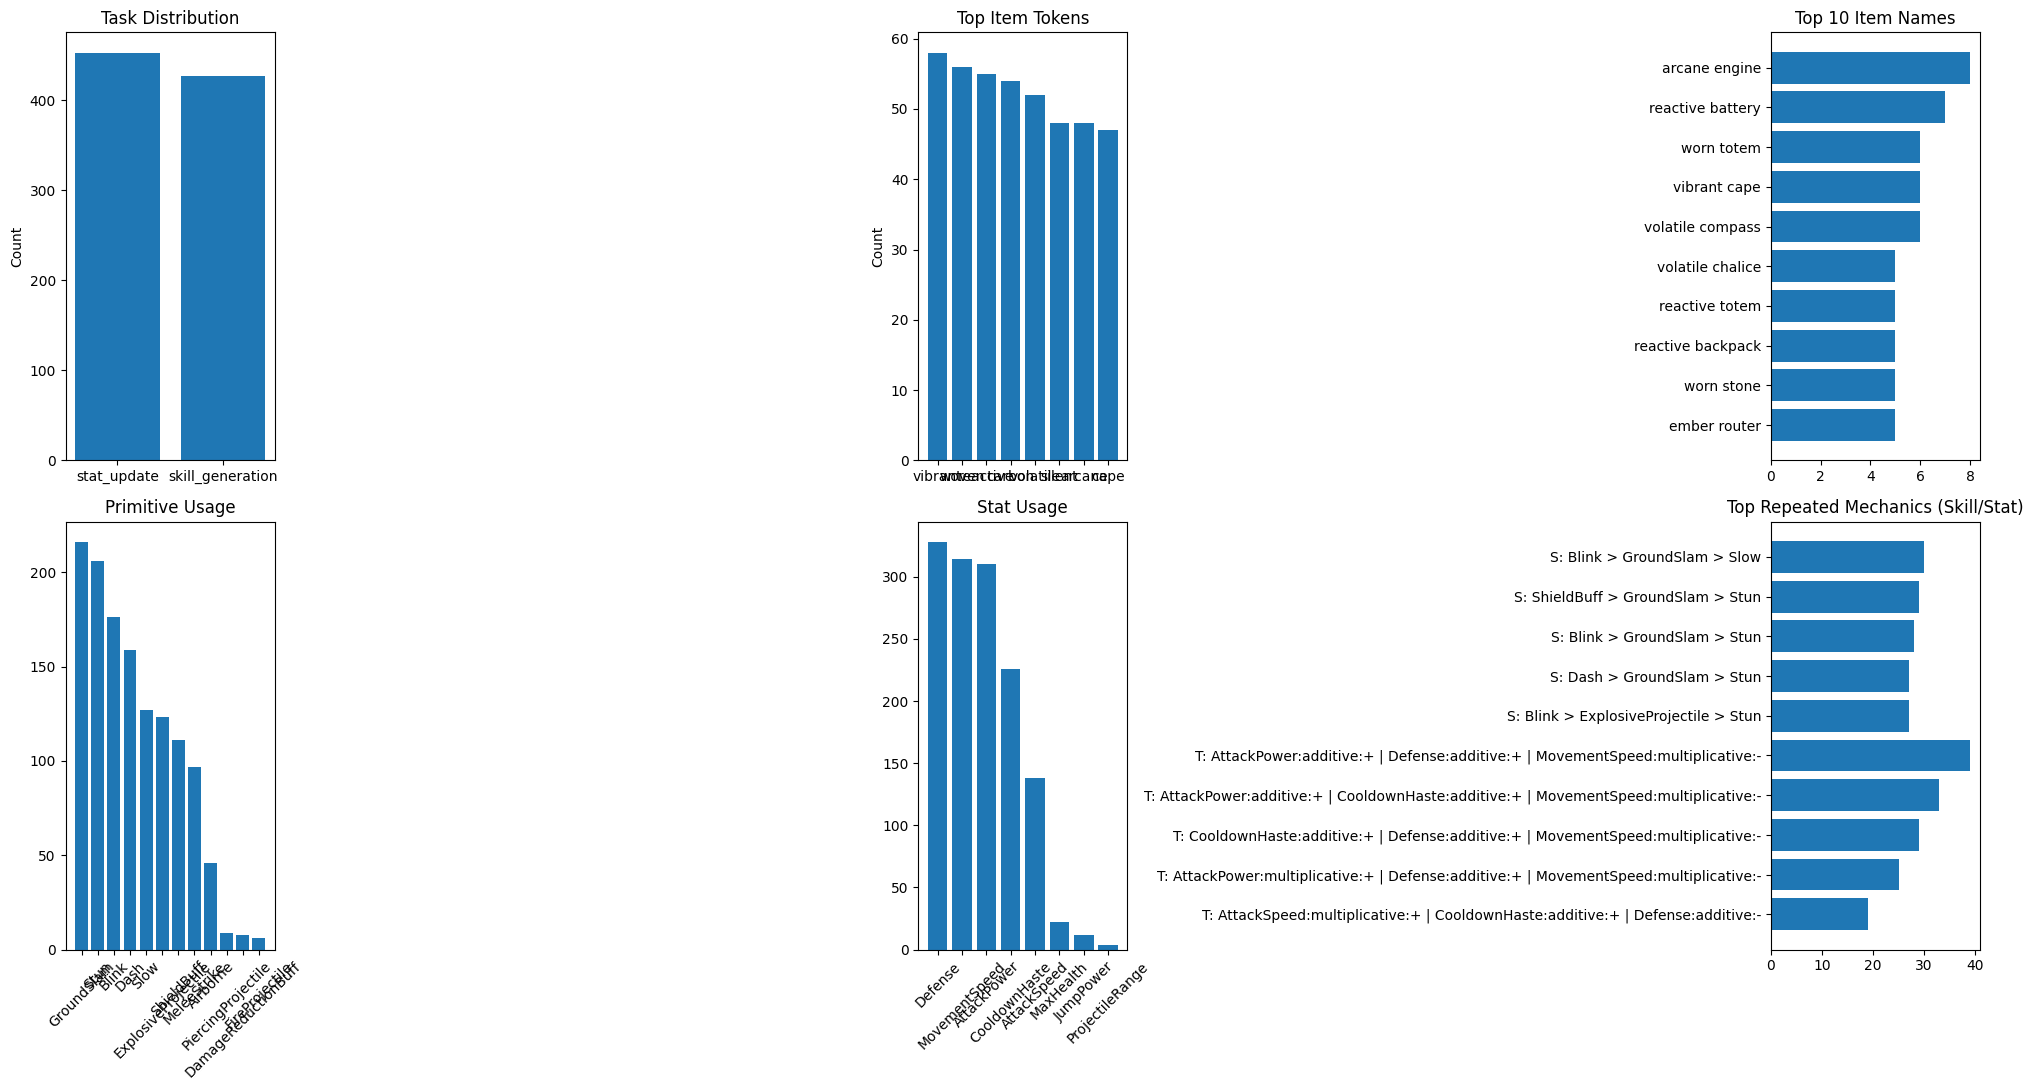

In [9]:
import os
from typing import Dict
import json
import math
import re
from collections import Counter

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'matplotlib'])
    import matplotlib.pyplot as plt

EVAL_SPLITS = ['train', 'validation', 'test']
EVAL_FILES = [os.path.join(OUTPUT_DIR, f'{split}.jsonl') for split in EVAL_SPLITS]

TAG_RE = re.compile(r'<(?P<tag>\w+)>(.*?)</(?P=tag)>', re.DOTALL)

def parse_user_tags(user_text: str) -> Dict[str, str]:
    tags: Dict[str, str] = {}
    for m in TAG_RE.finditer(user_text):
        tags[m.group('tag')] = m.group(2).strip()
    return tags

def normalize_eval_text(text: str) -> str:
    text = (text or '').strip().lower()
    text = re.sub(r'[^a-z0-9]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def change_direction(change_type: str, value: float) -> str:
    if change_type == 'multiplicative':
        if value > 1.0:
            return '+'
        if value < 1.0:
            return '-'
        return '0'
    if value > 0.0:
        return '+'
    if value < 0.0:
        return '-'
    return '0'

all_rows = []
for file_path in EVAL_FILES:
    if not os.path.exists(file_path):
        continue
    split_name = os.path.splitext(os.path.basename(file_path))[0]
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            row = json.loads(line)
            messages = row['messages']
            user_text = next(m['content'] for m in messages if m['role'] == 'user')
            assistant = json.loads(next(m['content'] for m in messages if m['role'] == 'assistant'))
            task = 'stat_update' if '<task>stat_update</task>' in user_text else 'skill_generation'
            tags = parse_user_tags(user_text)
            all_rows.append((split_name, task, tags, assistant))

if not all_rows:
    raise RuntimeError(f'No rows found in {EVAL_FILES}. Run generation first.')

task_counter = Counter(task for _, task, _, _ in all_rows)
item_counter = Counter(normalize_eval_text(tags.get('item_name', '')) for _, _, tags, _ in all_rows)
item_counter = Counter({k: v for k, v in item_counter.items() if k})

token_counter = Counter()
for item_name, count in item_counter.items():
    for token in item_name.split():
        if len(token) >= 3:
            token_counter[token] += count

primitive_counter = Counter()
skill_sequence_counter = Counter()
for _, task, _, assistant in all_rows:
    if task != 'skill_generation':
        continue
    primitives = assistant.get('NewSkill', {}).get('primitiveActions', [])
    sequence = ' > '.join(primitives)
    skill_sequence_counter[sequence] += 1
    for primitive in primitives:
        primitive_counter[primitive] += 1

stat_counter = Counter()
stat_signature_counter = Counter()
for _, task, _, assistant in all_rows:
    if task != 'stat_update':
        continue
    changes = assistant.get('statChanges', [])
    signature_parts = []
    for change in changes:
        stat = change.get('stat', '')
        change_type = change.get('changeType', '')
        value = float(change.get('value', 0.0))
        direction = change_direction(change_type, value)
        signature_parts.append(f'{stat}:{change_type}:{direction}')
        stat_counter[stat] += 1
    stat_signature_counter[' | '.join(sorted(signature_parts))] += 1

total_rows = len(all_rows)
item_unique_ratio = (len(item_counter) / total_rows) if total_rows else 0.0
top_item_share = (item_counter.most_common(1)[0][1] / total_rows) if item_counter else 0.0

print('=== Dataset Diversity Snapshot ===')
print(f'Total rows: {total_rows}')
print(f'Task counts: {dict(task_counter)}')
print(f'Unique item names: {len(item_counter)} ({item_unique_ratio:.1%})')
print(f'Top item share: {top_item_share:.1%}')
print('Top item tokens:', token_counter.most_common(8))
print(f"Unique skill sequences: {len(skill_sequence_counter)} / {max(1, task_counter.get('skill_generation', 0))}")
print(f"Unique stat signatures: {len(stat_signature_counter)} / {max(1, task_counter.get('stat_update', 0))}")

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# 1) Task distribution
task_labels = list(task_counter.keys())
task_values = [task_counter[k] for k in task_labels]
axes[0, 0].bar(task_labels, task_values)
axes[0, 0].set_title('Task Distribution')
axes[0, 0].set_ylabel('Count')

# 2) Top item tokens
top_tokens = token_counter.most_common(8)
if top_tokens:
    keys = [k for k, _ in top_tokens]
    vals = [v for _, v in top_tokens]
else:
    keys = ['(none)']
    vals = [0]
axes[0, 1].bar(keys, vals)
axes[0, 1].set_title('Top Item Tokens')
axes[0, 1].set_ylabel('Count')

# 3) Top item names
top_items = item_counter.most_common(10)
item_labels = [k for k, _ in top_items][::-1]
item_vals = [v for _, v in top_items][::-1]
axes[0, 2].barh(item_labels, item_vals)
axes[0, 2].set_title('Top 10 Item Names')

# 4) Primitive usage
prim_labels = [k for k, _ in primitive_counter.most_common()]
prim_vals = [v for _, v in primitive_counter.most_common()]
axes[1, 0].bar(prim_labels, prim_vals)
axes[1, 0].set_title('Primitive Usage')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5) Stat usage
stat_labels = [k for k, _ in stat_counter.most_common()]
stat_vals = [v for _, v in stat_counter.most_common()]
axes[1, 1].bar(stat_labels, stat_vals)
axes[1, 1].set_title('Stat Usage')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6) Top mechanic signatures
top_skill_seq = skill_sequence_counter.most_common(5)
top_stat_sig = stat_signature_counter.most_common(5)
labels = [f'S: {k}' for k, _ in top_skill_seq] + [f'T: {k}' for k, _ in top_stat_sig]
vals = [v for _, v in top_skill_seq] + [v for _, v in top_stat_sig]
order = list(range(len(labels)))[::-1]
axes[1, 2].barh([labels[i] for i in order], [vals[i] for i in order])
axes[1, 2].set_title('Top Repeated Mechanics (Skill/Stat)')

plt.tight_layout()
plt.show()
